# Kalibracja Kamey i Stereowizja

## Kalibracja pojedynczej kamery

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# termination criteria
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
calibration_flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC + cv2.fisheye.CALIB_FIX_SKEW

# inner size of chessboard
width = 9
height = 6
square_size = 0.025  # 0.025 meters

# prepare object points
objp = np.zeros((height * width, 1, 3), np.float64)
objp[:, 0, :2] = np.mgrid[0:width, 0:height].T.reshape(-1, 2)
objp = objp * square_size  # Create real world coords

# Arrays to store object points and image points
objpoints = []  # 3D points in real world space
imgpoints = []  # 2D points in image plane

img_width = 640
img_height = 480
image_size = (img_width, img_height)

path = "./"
read_image_dir = path + "pairs/"
write_image_dir = path + "undistorted_pairs/"
number_of_images = 50

for i in range(1, number_of_images):
    # read image
    img = cv2.imread(read_image_dir + "left_%02d.png" % i)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Find the chess board corners
    ret, corners = cv2.findChessboardCorners(gray, (width, height),
                                             cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK +
                                             cv2.CALIB_CB_NORMALIZE_IMAGE)
    Y, X, channels = img.shape
    
    # Skip images where the corners are too close to edges
    if ret:
        minRx = corners[:, :, 0].min()
        maxRx = corners[:, :, 0].max()
        minRy = corners[:, :, 1].min()
        maxRy = corners[:, :, 1].max()
        border_threshold_x = X / 12
        border_threshold_y = Y / 12
        
        x_thresh_bad = minRx < border_threshold_x
        y_thresh_bad = minRy < border_threshold_y
        
        if x_thresh_bad or y_thresh_bad:
            continue
        
        # If found, add object points and refine image points
        objpoints.append(objp)
        corners2 = cv2.cornerSubPix(gray, corners, (3, 3), (-1, -1), criteria)
        imgpoints.append(corners2)
        
        # Draw and display the corners
        cv2.drawChessboardCorners(img, (width, height), corners2, ret)
        cv2.imshow("Corners", img)
        cv2.waitKey(10)

    else:
        print("Chessboard couldn’t be detected. Image pair:", i)
        continue

# Camera calibration
N_OK = len(objpoints)
K = np.zeros((3, 3))
D = np.zeros((4, 1))
rvecs = [np.zeros((1, 1, 3), dtype=np.float64) for _ in range(N_OK)]
tvecs = [np.zeros((1, 1, 3), dtype=np.float64) for _ in range(N_OK)]

ret, K, D, _, _ = cv2.fisheye.calibrate(
    objpoints,
    imgpoints,
    image_size,
    K,
    D,
    rvecs,
    tvecs,
    calibration_flags,
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6)
)

# Rectify results
map1, map2 = cv2.fisheye.initUndistortRectifyMap(K, D, np.eye(3), K, image_size, cv2.CV_16SC2)

cv2.destroyAllWindows()

print(f"K = {K}")
print(f"D = {D}")


K = [[335.39124594   0.         345.29455183]
 [  0.         335.22283549 232.92700067]
 [  0.           0.           1.        ]]
D = [[-0.02430673]
 [-0.018878  ]
 [ 0.02584017]
 [-0.01508828]]


Text(0.5, 1.0, 'undistorted_image')

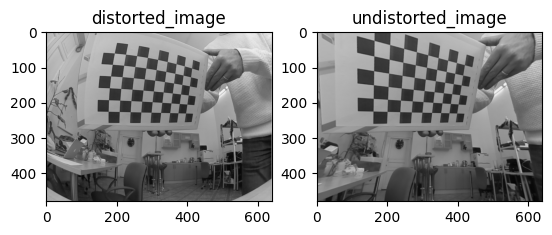

In [12]:
path = "./"
read_image_dir = path + "pairs/"
write_image_dir = path + "undistorted_pairs/"

img = cv2.imread(read_image_dir + "left_%02d.png" % 23)

undistorted_image = cv2.remap(
    img, map1, map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT
)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(img)
axes[0].set_title("distorted_image")
axes[1].imshow(undistorted_image)
axes[1].set_title("undistorted_image")

In [13]:
for i in range(1, number_of_images):
    # read image
    img = cv2.imread(read_image_dir + "right_%02d.png" % i)
    undistorted_image = cv2.remap(
        img, map1, map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT
    )
    img = cv2.imwrite(write_image_dir + "right_%02d.png" % i, undistorted_image)

In [14]:
for i in range(1, number_of_images):
    # read image
    img = cv2.imread(read_image_dir + "left_%02d.png" % i)
    undistorted_img = cv2.imread(write_image_dir + "left_%02d.png" % i)

    glued_imgs = cv2.hconcat((img, undistorted_img))

    cv2.imshow("Comparison", glued_imgs)
    cv2.waitKey(70)

cv2.destroyAllWindows()

## Kalibracja układu kamer

In [15]:
# Convert image points to numpy arrays
imgpointsLeft = np.asarray(imgpointsLeft, dtype=np.float64)
imgpointsRight = np.asarray(imgpointsRight, dtype=np.float64)

# Stereo calibration
(RMS, _, _, _, _, rotationMatrix, translationVector) = cv2.fisheye.stereoCalibrate(
    objpoints, imgpointsLeft, imgpointsRight,
    K_left, D_left,
    K_right, D_right,
    image_size, None, None,
    cv2.CALIB_FIX_INTRINSIC,
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.01)
)

R2 = np.zeros([3, 3])
P1 = np.zeros([3, 4])
P2 = np.zeros([3, 4])
Q = np.zeros([4, 4])

# Rectify calibration results
(leftRectification, rightRectification, leftProjection, rightProjection,
disparityToDepthMap) = cv2.fisheye.stereoRectify(
    K_left, D_left,
    K_right, D_right,
    image_size,
    rotationMatrix, translationVector,
    0, R2, P1, P2, Q,
    cv2.CALIB_ZERO_DISPARITY, (0, 0), 0, 0
)

map1_left, map2_left = cv2.fisheye.initUndistortRectifyMap(
    K_left, D_left, leftRectification,
    leftProjection, image_size, cv2.CV_16SC2
)
map1_right, map2_right = cv2.fisheye.initUndistortRectifyMap(
    K_right, D_right, rightRectification,
    rightProjection, image_size, cv2.CV_16SC2
)

# Load two images and apply remapping
dst_L = cv2.remap(img_l, map1_left, map2_left, cv2.INTER_LINEAR)
dst_R = cv2.remap(img_r, map1_right, map2_right, cv2.INTER_LINEAR)

# Check rectification by placing images side by side
N, XX, YY = dst_L.shape[::-1]  # RGB image size
visRectify = np.zeros((YY, XX * 2, N), np.uint8)  # create a new image with double width
visRectify[:, 0:XX, :] = dst_L  # left image assignment
visRectify[:, XX:XX * 2, :] = dst_R  # right image assignment

# Draw horizontal lines
for y in range(0, YY, 10):
    cv2.line(visRectify, (0, y), (XX * 2, y), (255, 0, 0))

# Display the rectified image with lines
cv2.imshow('visRectify', visRectify)
cv2.waitKey(0)
cv2.destroyAllWindows()

NameError: name 'imgpointsLeft' is not defined